# Class 12: Model Evaluation & Metrics
### আমরা কীভাবে বুঝব যে আমাদের Model টা আসলেই ভালো?

এই ক্লাসে আমরা শিখব:
- Regression Metrics (MAE, MSE, RMSE, R²)
- Classification Metrics (Accuracy, Precision, Recall, F1)
- Confusion Matrix
- ROC Curve এবং AUC
- Overfitting vs Underfitting
- Bias-Variance Tradeoff
- Learning Curves

---


## কেন Model Evaluation দরকার?

- একটা Model যদি Training Data-তে perfectly fit করে, তার মানে এই না যে সেটা আসলে ভালো Model।
- আমাদের দরকার objective, numerical উপায় যাতে বলতে পারি — "এই Model কি যথেষ্ট ভালো?"
- Regression আর Classification সমস্যার জন্য আলাদা আলাদা Metric লাগে।
- ভুল Metric বেছে নিলে সেটা বড় সমস্যাকে আড়াল করে ফেলতে পারে (বিশেষত Imbalanced Data-তে)।


In [ ]:
# প্রয়োজনীয় Library গুলো Import করে নিচ্ছি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression, make_classification

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7, 5)

print("সব Library Successfully Import হয়ে গেছে!")


সব Library Successfully Import হয়ে গেছে!


---
## Part 1: Regression Metrics

প্রথমে আমরা একটা synthetic Regression Dataset বানাবো, একটা Linear Regression Model Train করব, তারপর সেই Model-এর Prediction গুলো কেমন হলো সেটা বিভিন্ন Metric দিয়ে মাপব।


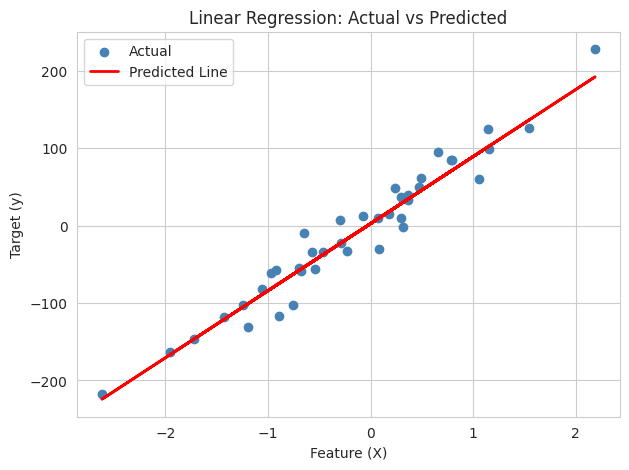

In [ ]:
# একটা Synthetic Regression Dataset তৈরি করছি
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Train করছি
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Test Data-তে Prediction
y_pred = reg_model.predict(X_test)

plt.scatter(X_test, y_test, color="steelblue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted Line")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()


### 1.1 Mean Absolute Error (MAE)

- Predicted আর Actual value-এর মধ্যে Absolute পার্থক্যের গড় (Average)।
- **Formula:** MAE = (1/n) Σ |yᵢ − ŷᵢ|
- বোঝা সহজ — কারণ এটা Target-এর মতোই Unit-এ থাকে।
- সব Error-কে সমানভাবে (Linearly) Treat করে।
- Outlier-এর প্রতি কম Sensitive।


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (Mean Absolute Error): {mae:.3f}")


MAE (Mean Absolute Error): 16.041


### 1.2 Mean Squared Error (MSE)

- Predicted আর Actual value-এর মধ্যে পার্থক্যের Square-এর গড়।
- **Formula:** MSE = (1/n) Σ (yᵢ − ŷᵢ)²
- Square করার কারণে বড় Error-গুলোকে বেশি Penalize করে।
- Unit Square হয়ে যায় বলে সরাসরি Interpret করা কঠিন।
- Outlier-এর প্রতি খুবই Sensitive।


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE (Mean Squared Error): {mse:.3f}")


MSE (Mean Squared Error): 437.550


### 1.3 Root Mean Squared Error (RMSE)

- MSE-এর Square Root।
- **Formula:** RMSE = √MSE
- আবার Original Unit-এ ফিরে আসে — তাই MSE-এর চেয়ে সহজে বোঝা যায়।
- তবুও Outlier-এর প্রতি Sensitive (কারণ এটা Squared Error থেকে এসেছে)।
- সবচেয়ে বেশি ব্যবহৃত Regression Metric।


In [ ]:
rmse = np.sqrt(mse)
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")


RMSE (Root Mean Squared Error): 20.918


### 1.4 R² (R-Squared / Coefficient of Determination)

- Target-এর Variance-এর কত অংশ Model ব্যাখ্যা করতে পারছে সেটা মাপে।
- **Formula:** R² = 1 − (SS_residual / SS_total)
- Range: −∞ থেকে 1 (1 মানে Perfect Fit, 0 মানে শুধু Mean Predict করার সমান)।
- যত বেশি, তত ভালো।
- এটা Error-এর Size সম্পর্কে কিছু বলে না — তাই MAE/RMSE-এর সাথে একসাথে দেখা উচিত।


In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.3f}")

print("\n--- সব Regression Metric একসাথে ---")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


R² Score: 0.945

--- সব Regression Metric একসাথে ---
MAE  : 16.041
MSE  : 437.550
RMSE : 20.918
R²   : 0.945


### 1.5 কোন Regression Metric কখন বাছবো?

- Original Unit-এ Error দেখতে চাও? → RMSE অথবা MAE
- বড় Error-কে বেশি Punish করতে চাও? → RMSE / MSE
- Model কতটুকু Pattern ধরতে পেরেছে জানতে চাও? → R²
- **Best Practice:** একটার বদলে একাধিক Metric একসাথে Report করা ভালো।


---
## Part 2: Classification Metrics

এবার একটা Binary Classification Dataset বানিয়ে Logistic Regression Model দিয়ে Train করব।


In [ ]:
# একটা Synthetic, একটু Imbalanced Classification Dataset বানাচ্ছি
X_cls, y_cls = make_classification(
    n_samples=500, n_features=5, n_informative=3,
    n_redundant=1, weights=[0.75, 0.25], random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

clf_model = LogisticRegression()
clf_model.fit(X_train_c, y_train_c)

y_pred_c = clf_model.predict(X_test_c)
y_proba_c = clf_model.predict_proba(X_test_c)[:, 1]   # ROC/AUC এর জন্য দরকার হবে

print("Class Distribution (Test Set):")
print(pd.Series(y_test_c).value_counts())


Class Distribution (Test Set):
0    94
1    31
Name: count, dtype: int64


### 2.1 Accuracy

- মোট Prediction-এর মধ্যে কতগুলো সঠিক হয়েছে তার Proportion।
- **Formula:** Accuracy = (TP + TN) / (TP + TN + FP + FN)
- সহজ ও Intuitive।
- কিন্তু **Imbalanced Dataset-এ Misleading** — উদাহরণস্বরূপ, যদি Data-এর 95% এক Class-এর হয়, তাহলে সবসময় সেই Class Predict করলেও 95% Accuracy পাওয়া যাবে, যেটা আসলে কিছুই বোঝায় না।


In [ ]:
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {acc:.3f}")


Accuracy: 0.864


### 2.2 Precision

- যতগুলো Prediction Positive বলা হয়েছে, তার মধ্যে কতগুলো আসলেই Positive ছিল?
- **Formula:** Precision = TP / (TP + FP)
- False Positive-এর Cost বেশি হলে এটা গুরুত্বপূর্ণ।
- উদাহরণ: Spam Detection — আসল Email-কে ভুলে Spam বলে ফেলা যাবে না।


In [ ]:
precision = precision_score(y_test_c, y_pred_c)
print(f"Precision: {precision:.3f}")


Precision: 0.750


### 2.3 Recall (Sensitivity)

- আসলে যতগুলো Positive ছিল, তার মধ্যে কতগুলো আমরা সঠিকভাবে ধরতে পেরেছি?
- **Formula:** Recall = TP / (TP + FN)
- False Negative-এর Cost বেশি হলে এটা গুরুত্বপূর্ণ।
- উদাহরণ: রোগ শনাক্তকরণ — কোনো অসুস্থ রোগীকে Miss করা যাবে না।


In [ ]:
recall = recall_score(y_test_c, y_pred_c)
print(f"Recall: {recall:.3f}")


Recall: 0.677


### 2.4 F1 Score

- Precision এবং Recall-এর Harmonic Mean।
- **Formula:** F1 = 2 × (Precision × Recall) / (Precision + Recall)
- Precision আর Recall-এর মধ্যে Balance দরকার হলে এটা কাজে লাগে।
- বিশেষভাবে Imbalanced Dataset-এর জন্য Useful।


In [ ]:
f1 = f1_score(y_test_c, y_pred_c)
print(f"F1 Score: {f1:.3f}")

print("\n--- সব Classification Metric একসাথে ---")
print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")


F1 Score: 0.712

--- সব Classification Metric একসাথে ---
Accuracy  : 0.864
Precision : 0.750
Recall    : 0.677
F1 Score  : 0.712


### 2.5 Precision vs Recall — Tradeoff

- একটা বাড়ালে সাধারণত অন্যটা কমে যায়।
- Classification Threshold পরিবর্তন করলে এই Balance Shift হয়।
- Real-World Cost অনুযায়ী সিদ্ধান্ত নিতে হয়:
  - **High Precision** দরকার → Spam Filter, Fraud Alert
  - **High Recall** দরকার → Medical Screening, Security Threat Detection


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-

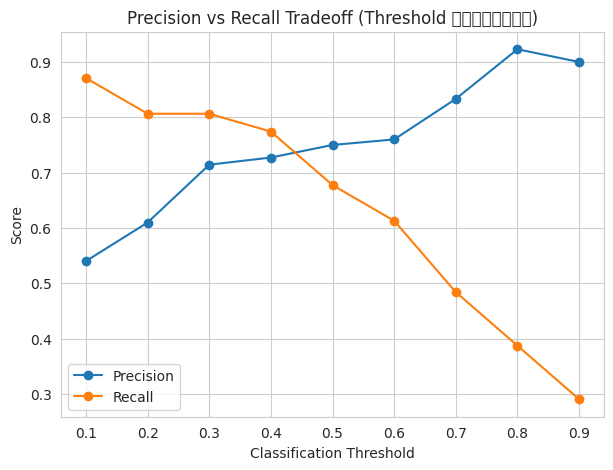

In [ ]:
# Threshold পরিবর্তন করলে Precision আর Recall কীভাবে বদলায় সেটা দেখি
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls = [], []

for t in thresholds:
    y_pred_t = (y_proba_c >= t).astype(int)
    precisions.append(precision_score(y_test_c, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test_c, y_pred_t, zero_division=0))

plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='o', label="Recall")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Tradeoff (Threshold অনুযায়ী)")
plt.legend()
plt.show()


---
## Part 3: Confusion Matrix

### Confusion Matrix কী?

একটা Table যা Predicted vs Actual Classification দেখায়। চারটা সম্ভাব্য Outcome থাকে:

- **True Positive (TP)** — সঠিকভাবে Positive Predict করা হয়েছে
- **True Negative (TN)** — সঠিকভাবে Negative Predict করা হয়েছে
- **False Positive (FP)** — ভুলভাবে Positive বলা হয়েছে (Type I Error)
- **False Negative (FN)** — ভুলভাবে Negative বলা হয়েছে (Type II Error)

### কীভাবে পড়বো?

- Row = Actual Class, Column = Predicted Class (অথবা উল্টো)
- Diagonal-এর মানগুলো = সঠিক Prediction
- Off-diagonal = Error
- Accuracy, Precision, Recall, F1 — সবকিছু এই Matrix থেকেই বের করা যায়।


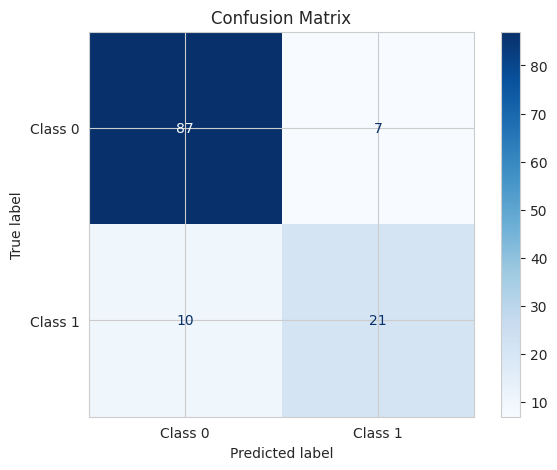

Confusion Matrix (Raw):
[[87  7]
 [10 21]]

TN: 87, FP: 7, FN: 10, TP: 21


In [ ]:
cm = confusion_matrix(y_test_c, y_pred_c)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix (Raw):")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")


---
## Part 4: ROC Curve এবং AUC

### ROC Curve (Receiver Operating Characteristic)

- বিভিন্ন Threshold-এ True Positive Rate (Recall) vs False Positive Rate Plot করে।
- Positive ধরতে পারা আর False Alarm দেওয়ার মধ্যে Tradeoff দেখায়।
- Diagonal Line মানে Random Guessing।

### AUC (Area Under the Curve)

- ROC Curve-কে একটামাত্র সংখ্যায় Summarize করে।
- Range: 0 থেকে 1
  - **1.0** = Perfect Classifier
  - **0.5** = Random Guessing-এর চেয়ে ভালো না
  - **< 0.5** = Random-এর চেয়েও খারাপ
- AUC যত বেশি, Model সব Threshold-এ Class দুটোকে আলাদা করতে তত ভালো।


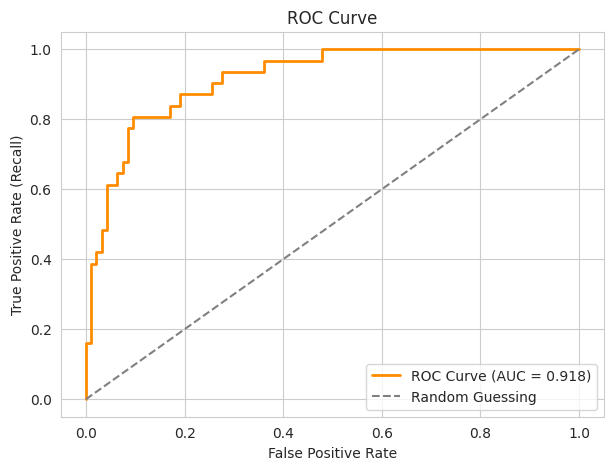

AUC Score: 0.918


In [ ]:
fpr, tpr, thresholds_roc = roc_curve(y_test_c, y_proba_c)
auc_score = roc_auc_score(y_test_c, y_proba_c)

plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.3f}")


---
## Part 5: Overfitting vs Underfitting

### Underfitting

- Model অনেক Simple, তাই Underlying Pattern ধরতে পারে না।
- Training এবং Test — দুই জায়গাতেই খারাপ Performance।
- লক্ষণ: High Bias, Low Variance
- কারণ: খুব কম Feature, খুবই Simple Model, অপর্যাপ্ত Training

### Overfitting

- Model Training Data থেকে Noise সহ সবকিছু মুখস্থ করে ফেলে।
- Training Data-তে দারুণ Performance, কিন্তু Test Data-তে খারাপ।
- লক্ষণ: Low Bias, High Variance
- কারণ: খুব Complex Model, খুব কম Data, অতিরিক্ত Feature

### সঠিক Fit খুঁজে বের করা

- **Goal:** এমন একটা Model যেটা Unseen Data-তেও ভালো Generalize করে।
- Underfitting ঠিক করতে: Feature বাড়াও, Model Complexity বাড়াও, বেশি Train করো।
- Overfitting ঠিক করতে: Regularization, বেশি Training Data, Model Simplify করা, Cross-Validation, Early Stopping।

নিচে আমরা Polynomial Regression দিয়ে Underfitting, Good Fit, আর Overfitting — তিনটাই Visually দেখব।


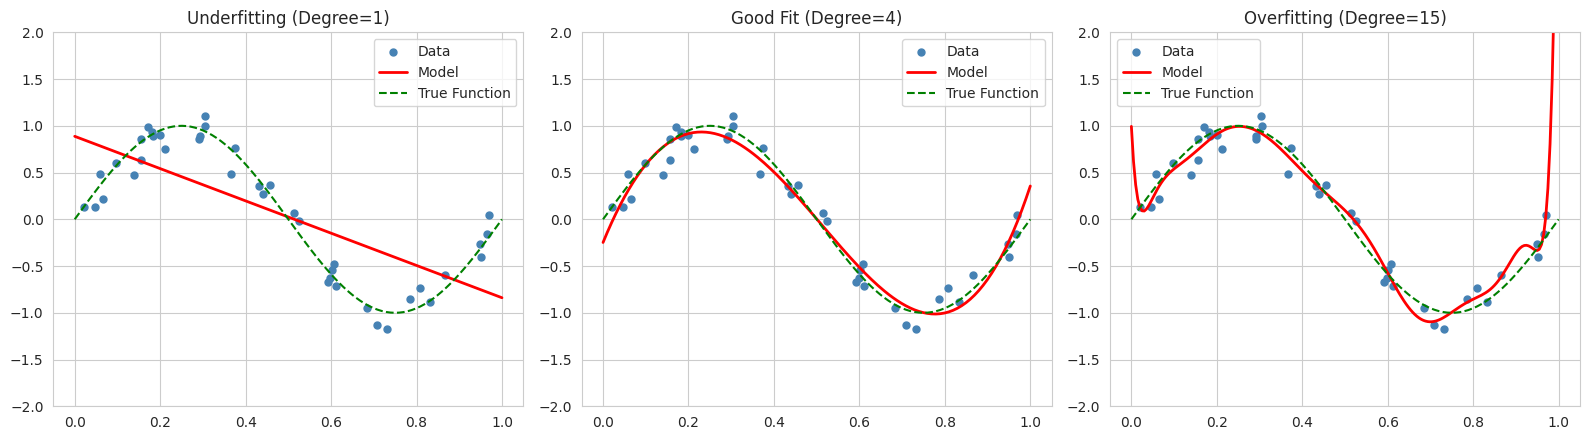

In [ ]:
# Non-linear Data তৈরি করছি (একটা sine curve + noise)
rng = np.random.RandomState(42)
X_nl = np.sort(rng.uniform(0, 1, 40)).reshape(-1, 1)
y_nl = np.sin(2 * np.pi * X_nl).ravel() + rng.normal(0, 0.15, X_nl.shape[0])

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

degrees = [1, 4, 15]   # Underfit, Good Fit, Overfit
titles = ["Underfitting (Degree=1)", "Good Fit (Degree=4)", "Overfitting (Degree=15)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, degree, title in zip(axes, degrees, titles):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_nl, y_nl)
    y_plot = model.predict(X_plot)

    ax.scatter(X_nl, y_nl, color="steelblue", s=25, label="Data")
    ax.plot(X_plot, y_plot, color="red", linewidth=2, label="Model")
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), color="green", linestyle="--", label="True Function")
    ax.set_ylim(-2, 2)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


---
## Part 6: Bias-Variance Tradeoff

### Bias

- Model-এর অতিরিক্ত Simplistic Assumption থেকে আসা Error।
- High Bias → Model Relevant Pattern Miss করে (Underfitting)।

### Variance

- Model Training Data-এর ছোটখাটো পরিবর্তনের প্রতি অতিরিক্ত Sensitive হলে যে Error হয়।
- High Variance → Model Noise-কেও Signal মনে করে ফেলে (Overfitting)।

### Tradeoff

**Total Error = Bias² + Variance + Irreducible Error**

- Simple Model → High Bias, Low Variance
- Complex Model → Low Bias, High Variance
- **Goal:** এমন একটা Sweet Spot খুঁজে বের করা যেখানে Total Error সবচেয়ে কম হয়।

নিচে বিভিন্ন Polynomial Degree-এর জন্য Training আর Test Error Plot করে Tradeoff-টা দেখানো হলো।


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


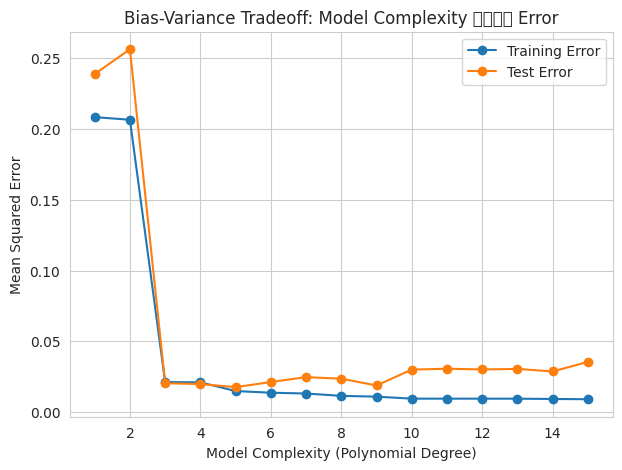

লক্ষ্য করো: Degree কম থাকলে (Left Side) দুটো Error-ই বেশি -> Underfitting (High Bias)।
Degree বেশি হলে (Right Side) Training Error কমতে থাকে কিন্তু Test Error বাড়ে -> Overfitting (High Variance)।


In [ ]:
degrees_range = range(1, 16)
train_errors, test_errors = [], []

X_tr, X_te, y_tr, y_te = train_test_split(X_nl, y_nl, test_size=0.3, random_state=42)

for d in degrees_range:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    train_errors.append(mean_squared_error(y_tr, train_pred))
    test_errors.append(mean_squared_error(y_te, test_pred))

plt.plot(list(degrees_range), train_errors, marker='o', label="Training Error")
plt.plot(list(degrees_range), test_errors, marker='o', label="Test Error")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff: Model Complexity বনাম Error")
plt.legend()
plt.show()

print("লক্ষ্য করো: Degree কম থাকলে (Left Side) দুটো Error-ই বেশি -> Underfitting (High Bias)।")
print("Degree বেশি হলে (Right Side) Training Error কমতে থাকে কিন্তু Test Error বাড়ে -> Overfitting (High Variance)।")


---
## Part 7: Learning Curves

### Learning Curve কী?

- Training Set Size বা Training Iteration-এর সাপেক্ষে Model Performance (Error/Accuracy)-এর একটা Plot।
- সাধারণত দুইটা Line থাকে: Training Score আর Validation Score।
- Model Underfitting নাকি Overfitting করছে সেটা Diagnose করতে সাহায্য করে।

### Learning Curve কীভাবে পড়বো?

- **Underfitting:** Training এবং Validation Error দুটোই বেশি, এবং কাছাকাছি।
- **Overfitting:** Training Error কম, কিন্তু Validation Error অনেক বেশি (বড় Gap)।
- **Good Fit:** দুটো Error-ই কমে গিয়ে একটা কাছাকাছি, নিচু Value-তে Converge করে।
- এটা এটাও বলে দিতে পারে যে আরও Data দিলে আদৌ কোনো লাভ হবে কিনা।


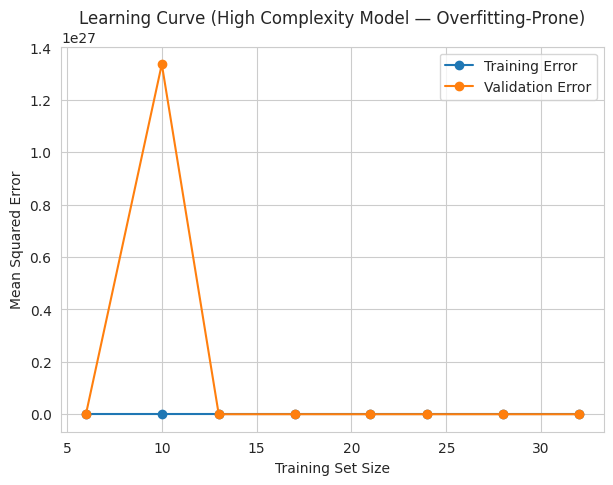

In [ ]:
# Overfit-prone (High Degree) Model দিয়ে Learning Curve দেখি
overfit_model = make_pipeline(PolynomialFeatures(12), LinearRegression())

train_sizes, train_scores, val_scores = learning_curve(
    overfit_model, X_nl, y_nl, cv=5,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring="neg_mean_squared_error"
)

train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, marker='o', label="Training Error")
plt.plot(train_sizes, val_scores_mean, marker='o', label="Validation Error")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve (High Complexity Model — Overfitting-Prone)")
plt.legend()
plt.show()


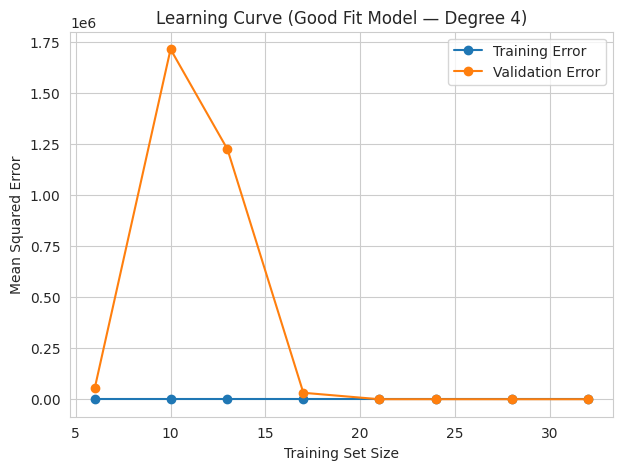

লক্ষ্য করো: এখানে Gap আগেরটার চেয়ে অনেক ছোট -> এটা একটা ভালো Fit-এর লক্ষণ।


In [ ]:
# তুলনার জন্য একটা Good-Fit Model-এর Learning Curve দেখি
good_model = make_pipeline(PolynomialFeatures(4), LinearRegression())

train_sizes2, train_scores2, val_scores2 = learning_curve(
    good_model, X_nl, y_nl, cv=5,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring="neg_mean_squared_error"
)

train_scores_mean2 = -train_scores2.mean(axis=1)
val_scores_mean2 = -val_scores2.mean(axis=1)

plt.plot(train_sizes2, train_scores_mean2, marker='o', label="Training Error")
plt.plot(train_sizes2, val_scores_mean2, marker='o', label="Validation Error")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve (Good Fit Model — Degree 4)")
plt.legend()
plt.show()

print("লক্ষ্য করো: এখানে Gap আগেরটার চেয়ে অনেক ছোট -> এটা একটা ভালো Fit-এর লক্ষণ।")


---
## Recap (Class 12)

| Category | Topics |
|---|---|
| **Regression** | MAE, MSE, RMSE, R² |
| **Classification** | Accuracy, Precision, Recall, F1, Confusion Matrix, ROC/AUC |
| **Model Behavior** | Overfitting, Underfitting, Bias-Variance Tradeoff |
| **Diagnostics** | Learning Curves |

### মনে রাখার মতো গুরুত্বপূর্ণ পয়েন্ট:

- শুধু একটা Metric-এর উপর নির্ভর করো না — সবসময় একাধিক Metric একসাথে দেখো।
- Imbalanced Dataset-এ Accuracy বিভ্রান্তিকর হতে পারে — Precision/Recall/F1 দেখো।
- Overfitting আর Underfitting দুটোই খারাপ — Sweet Spot খুঁজে বের করাই আসল কাজ।
- Learning Curve দেখলে বোঝা যায় বেশি Data দিলে লাভ হবে কিনা।

**পরের Class:** Real-World Use Case অনুযায়ী সঠিক Metric বেছে নেওয়া।
